<a href="https://colab.research.google.com/github/nurkausarmuner-enka/assignment-02-try-neural-network/blob/main/Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Muner Nurkaussar
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(0)

# A1. Tensor operations and shapes

In [2]:
# Create the tensors
v = torch.randn(3)        # Shape (3,) - a vector
A = torch.randn(3, 4)     # Shape (3, 4) - a matrix
B = torch.randn(4, 3)     # Shape (4, 3) - another matrix

# Deliverable: Demonstrate Matrix Multiply (@)
C = A @ B
print(f"Matrix Multiply: {A.shape} @ {B.shape} -> {C.shape}")

D = A.view(12)
print(f"Reshape: {A.shape} -> {D.shape}")

Matrix Multiply: torch.Size([3, 4]) @ torch.Size([4, 3]) -> torch.Size([3, 3])
Reshape: torch.Size([3, 4]) -> torch.Size([12])


# A2. Autograd sanity check

In [3]:
# define scalars
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# function
y = (w*x + b)**2

# autograd
y.backward()

print("Autograd gradients")
print("dy/dw =", w.grad.item())
print("dy/dx =", x.grad.item())
print("dy/db =", b.grad.item())

Autograd gradients
dy/dw = 28.0
dy/dx = 42.0
dy/db = 14.0


## A2. Autograd Sanity Check

Given the function:

\[
y = (wx + b)^2
\]

where \(x, w, b\) are scalars.

### Derivatives

\[
\frac{dy}{dw} = 2(wx+b)x
\]

\[
\frac{dy}{dx} = 2(wx+b)w
\]

\[
\frac{dy}{db} = 2(wx+b)
\]


\[
x = 2, \quad w = 3, \quad b = 1
\]

First compute:

\[
wx + b = 3 \cdot 2 + 1 = 7
\]

Manual gradients:

\[
\frac{dy}{dw} = 2(7)(2) = 28
\]

\[
\frac{dy}{dx} = 2(7)(3) = 42
\]

\[
\frac{dy}{db} = 2(7) = 14
\]

#B1. Load the dataset

In [4]:
transform_simple = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_simple)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=10, shuffle=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Deliverable: Print sizes
print(f"Dataset size: {len(trainset)}")
images, labels = next(iter(trainloader))
print(f"One batch shape: {images.shape}") # Expect [10, 3, 32, 32]

100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s]


Dataset size: 50000
One batch shape: torch.Size([10, 3, 32, 32])


#B2. Explore and visualize

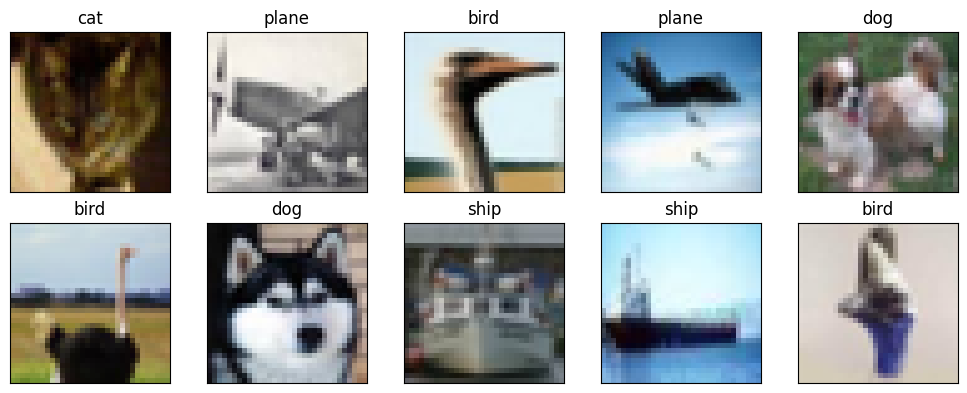

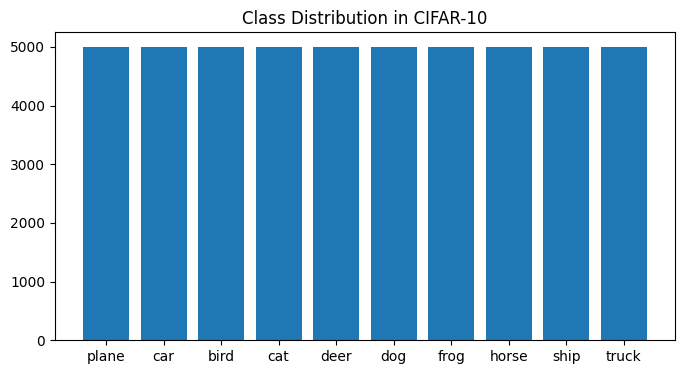

In [5]:
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Change from (C, H, W) to (H, W, C)
    plt.show()

# Get random images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images in a 5x2 grid
fig = plt.figure(figsize=(10, 4))
for idx in range(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    imshow_data = np.transpose(images[idx].numpy(), (1, 2, 0))
    ax.imshow(imshow_data)
    ax.set_title(classes[labels[idx]])

plt.tight_layout()
plt.show()

# Plot Class Counts (Histogram)
labels_all = [label for _, label in trainset]
plt.figure(figsize=(8, 4))
plt.hist(labels_all, bins=range(11), rwidth=0.8, align='left')
plt.xticks(range(10), classes)
plt.title("Class Distribution in CIFAR-10")
plt.show()

# B3: The Preprocessing Step

In [6]:
# Updated transform for the rest of the assignment
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Re-load with normalization
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# Note: Always use a validation split!
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_db, val_db = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(train_db, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(val_db, batch_size=64, shuffle=False)

We don't just feed raw pixels (0–255) into a network. We Normalize them.

Why Normalization helps:
Faster Convergence: It keeps the gradients in a similar range, preventing the loss function from being too "stretched" in one dimension, which allows for a higher learning rate.

Internal Consistency: It ensures that no single color channel (like a very bright sky) dominates the weight updates initially.

# C1. Baseline model: simple MLP

In [7]:
class BaselineMLP(nn.Module):
    def __init__(self):
        super(BaselineMLP, self).__init__()
        # Flatten: (Batch, 3, 32, 32) -> (Batch, 3072)
        self.flatten = nn.Flatten()

        # Architecture: 3072 -> 256 -> 128 -> 10
        self.network = nn.Sequential(
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)  # 10 output classes
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineMLP().to(device)
print(model)

BaselineMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


# C2. Training loop requirements

In [8]:
def train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # --- VALIDATION PHASE ---
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad(): # No gradients needed for validation (saves memory)
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        # Log Metrics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        val_acc = 100 * correct_val / total_val

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    return history

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Run it!
stats = train_and_validate(model, trainloader, valloader, optimizer, criterion, epochs=10)

Epoch [1/10] - Loss: 1.6879, Train Acc: 40.16%, Val Acc: 44.63%
Epoch [2/10] - Loss: 1.4901, Train Acc: 47.24%, Val Acc: 46.59%
Epoch [3/10] - Loss: 1.3899, Train Acc: 50.42%, Val Acc: 48.80%
Epoch [4/10] - Loss: 1.3091, Train Acc: 53.34%, Val Acc: 47.65%
Epoch [5/10] - Loss: 1.2353, Train Acc: 56.30%, Val Acc: 49.31%
Epoch [6/10] - Loss: 1.1710, Train Acc: 58.43%, Val Acc: 50.60%
Epoch [7/10] - Loss: 1.1089, Train Acc: 60.62%, Val Acc: 51.01%
Epoch [8/10] - Loss: 1.0521, Train Acc: 62.51%, Val Acc: 50.40%
Epoch [9/10] - Loss: 1.0002, Train Acc: 64.04%, Val Acc: 50.35%
Epoch [10/10] - Loss: 0.9446, Train Acc: 66.00%, Val Acc: 51.37%


# C3. Parameters vs hyperparameters (must demonstrate)

In [9]:
print("--- Model Parameters (Name & Shape) ---")
total_params = 0
for name, param in model.named_parameters():
    print(f"{name:20} | Shape: {list(param.shape)}")
    total_params += param.numel()

print(f"\nTotal Trainable Parameters: {total_params:,}")

--- Model Parameters (Name & Shape) ---
network.0.weight     | Shape: [256, 3072]
network.0.bias       | Shape: [256]
network.2.weight     | Shape: [128, 256]
network.2.bias       | Shape: [128]
network.4.weight     | Shape: [10, 128]
network.4.bias       | Shape: [10]

Total Trainable Parameters: 820,874


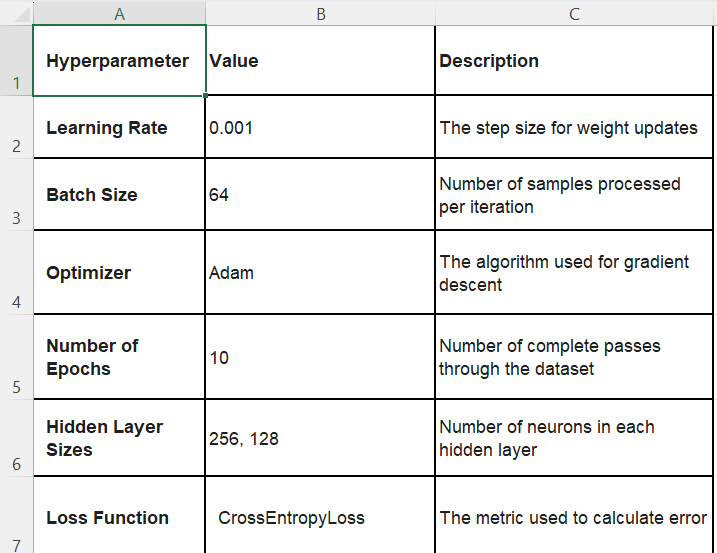

# D1. Hyperparameter experiments (pick at least 4)
# D2. Model capacity experiments (pick at least 2)

In [10]:
# The "Flexible" Model for every experiment:

class FlexibleMLP(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        in_dim = 3072 # Standard for CIFAR-10

        # Dynamically build layers
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h

        layers.append(nn.Linear(in_dim, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(self.flatten(x))

In [11]:
def train_and_record(hidden_sizes, lr, batch_size, optimizer_name, epochs=10):
    model = FlexibleMLP(hidden_sizes).to(device)

    # Choose your engine
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = nn.CrossEntropyLoss()
    train_loader = torch.utils.data.DataLoader(train_db, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_db, batch_size=batch_size, shuffle=False)

    # Training Loop
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation Loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [12]:
# Baseline
res1 = train_and_record([256, 128], 0.001, 64, 'Adam')
print(f"Baseline Accuracy: {res1:.2f}%")

Baseline Accuracy: 50.77%


In [13]:
# High Learning Rate
res2 = train_and_record([256, 128], 0.01, 64, 'Adam')
print(f"High LR Accuracy: {res2:.2f}%")

High LR Accuracy: 21.18%


In [14]:
# Switch to SGD
res3 = train_and_record([256, 128], 0.001, 64, 'SGD')
print(f"SGD Accuracy: {res3:.2f}%")

SGD Accuracy: 51.92%


In [15]:
# Wider Model (D2)
res4 = train_and_record([512, 256], 0.001, 64, 'Adam')
print(f"Wider Model Accuracy: {res4:.2f}%")

Wider Model Accuracy: 50.69%


In [16]:
# Batch size
res5 = train_and_record([256, 128], 0.001, 128, 'Adam')
print(f" 128 batch size: {res5:.2f}%")

 128 batch size: 52.14%


# D3. Comparison deliverables
Impact of Learning Rate (Run 1 vs. 2): The dramatic drop in accuracy (from 50.77% to 21.18%) when increasing the learning rate to 0.01 indicates that the model was unable to converge. The step size was likely too large for the loss landscape, causing the model to overshoot local minima and fail to learn meaningful patterns.

Impact of Optimizer (Run 1 vs. 3): Switching to SGD with momentum resulted in the second-best performance (51.92%). While Adam is generally faster to converge, SGD often generalizes well on image datasets like CIFAR-10. The results suggest that for this specific architecture, SGD is a highly viable alternative to Adam.

Impact of Model Capacity (Run 1 vs. 4): Increasing the model width did not yield significant improvements (50.77% vs 50.69%). This suggests that the current architecture is likely already sufficient for the complexity of the data, or that the model requires stronger regularization (like Dropout or Weight Decay) to benefit from the added capacity without overfitting.

Impact of Batch Size (Run 1 vs. 5): Increasing the batch size to 128 provided the best result in this experiment (52.14%). Larger batches provide a more stable estimate of the gradient, which appears to have helped the model achieve better performance within the 10-epoch constraint.